# MWE 37 - Trabecular bone 3-D ROI pore-network extraction

This notebook extracts pore networks from a 3-D ROI of the trabecular-bone RAW
segmentation, then estimates directional single-phase permeability along all
Cartesian axes.

Scientific scope and assumptions:

- the RAW filename convention is interpreted as `0_poro` = marrow/pore and
  `1_osso` = bone
- the RAW byte count is checked against the configured `(350, 350, 349)`
  `uint8` array before any analysis
- the default ROI is the central `100 x 100 x 100` voxel cube
- the extracted networks are 3-D PNM reductions of the binary ROI, not direct
  Stokes or micro-continuum solves on the image
- the reported `K` values depend on extraction backend, hydraulic conductance
  model, boundary labeling, and the ROI-scale sample geometry

In [1]:
from __future__ import annotations

import time
from pathlib import Path
from typing import Any

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

try:
    from IPython.display import display
except ImportError:  # pragma: no cover - notebook convenience fallback
    display = print

from voids.graph.metrics import connectivity_metrics, coordination_numbers
from voids.image import (
    extract_spanning_pore_network,
    has_spanning_cluster,
    infer_sample_axes,
)
from voids.io.hdf5 import save_hdf5
from voids.paths import data_path, project_root
from voids.physics.petrophysics import absolute_porosity, effective_porosity
from voids.physics.singlephase import (
    FluidSinglePhase,
    PressureBC,
    SinglePhaseOptions,
    solve,
)

# Keep script execution non-interactive; notebook frontends still render figures inline.
plt.ioff()

In [2]:
# User-editable inputs
raw_filename = "Trabecular_300_cubo_0_poro_1_osso_2086nm.raw"
raw_shape = (350, 350, 349)
raw_dtype = np.uint8
raw_order = "C"

bone_value = 1
marrow_value = 0
axis_labels = ("x", "y", "z")

# Use a central cubic ROI by default. Set `roi_start` explicitly if a fixed
# physical location is needed for a validation study.
roi_shape = (100, 100, 100)
roi_start: tuple[int, int, int] | None = None

voxel_size_nm = 2086.0
voxel_size_m = voxel_size_nm * 1.0e-9

flow_axes = ("x", "y", "z")
primary_backend = "native_maximal_ball"
primary_axis = "x"

fluid = FluidSinglePhase(viscosity=1.0e-3)
pressure_pin_pa = 1.0
pressure_pout_pa = 0.0
singlephase_options = SinglePhaseOptions(
    conductance_model="auto",
    solver="direct",
    check_mass_balance=True,
)

backend_specs = [
    {
        "backend": "native_maximal_ball",
        "label": "Native maximal-ball",
        "extraction_kwargs": {
            "distance_map_backend": "scipy",
            "apply_boundary_clipping": True,
            "flow_boundary_mode": "direct",
        },
        "geometry_repairs": None,
    },
    {
        "backend": "prego",
        "label": "PREGO",
        "extraction_kwargs": {
            "settings": {
                "r_max": 4,
                "sigma": 0.4,
                "peak_footprint": "sphere",
                "growth_mode": "level_queue",
                "distance_map_backend": "scipy",
            },
        },
        "geometry_repairs": None,
    },
    {
        "backend": "porespy",
        "label": "PoreSpy snow2",
        "extraction_kwargs": {
            "sigma": 0.4,
            "r_max": 4,
        },
        "geometry_repairs": "imperial_export",
    },
]

save_outputs = True
output_dir = (
    project_root()
    / "notebooks"
    / "outputs"
    / ("37_mwe_trabecular_bone_slice_pore_network")
)
output_dir.mkdir(parents=True, exist_ok=True)

M2_PER_MD = 9.869233e-16


def _candidate_raw_paths() -> list[Path]:
    """Return source paths in preference order without assuming an absolute checkout."""

    trabecular_root = data_path() / "trabecular-image"
    return [
        trabecular_root
        / "36_mwe_trabecular_bone_slice_porosity_permeability_maps"
        / raw_filename,
        trabecular_root / raw_filename,
    ]


candidate_raw_paths = _candidate_raw_paths()
raw_path = next(
    (path for path in candidate_raw_paths if path.exists()), candidate_raw_paths[0]
)
raw_path

PosixPath('/Users/dtvolpatto/Work/voids/examples/data/trabecular-image/36_mwe_trabecular_bone_slice_porosity_permeability_maps/Trabecular_300_cubo_0_poro_1_osso_2086nm.raw')

## Load and validate the binary ROI

The image is loaded as a memory map so that selecting a 3-D ROI does not
require materializing the full RAW volume.

In [3]:
if not raw_path.exists():
    raise FileNotFoundError(
        "Could not find the trabecular RAW volume. Checked:\n"
        + "\n".join(f"- {path}" for path in candidate_raw_paths)
    )

expected_voxels = int(np.prod(np.asarray(raw_shape, dtype=np.int64)))
actual_voxels = raw_path.stat().st_size // np.dtype(raw_dtype).itemsize
if expected_voxels != actual_voxels:
    raise ValueError(
        f"Configured shape {raw_shape} requires {expected_voxels:,} voxels, "
        f"but {raw_path.name} stores {actual_voxels:,}."
    )

roi_shape = tuple(int(v) for v in roi_shape)
if len(roi_shape) != 3 or any(v <= 0 for v in roi_shape):
    raise ValueError("roi_shape must contain three positive integers")
if any(r > s for r, s in zip(roi_shape, raw_shape, strict=True)):
    raise ValueError(f"roi_shape {roi_shape} must fit inside raw_shape {raw_shape}")

if roi_start is None:
    resolved_roi_start = tuple(
        (s - r) // 2 for s, r in zip(raw_shape, roi_shape, strict=True)
    )
else:
    resolved_roi_start = tuple(int(v) for v in roi_start)
if len(resolved_roi_start) != 3:
    raise ValueError("roi_start must contain three integers when provided")
roi_stop = tuple(a + b for a, b in zip(resolved_roi_start, roi_shape, strict=True))
if any(a < 0 for a in resolved_roi_start) or any(
    b > s for b, s in zip(roi_stop, raw_shape, strict=True)
):
    raise ValueError(
        f"ROI start {resolved_roi_start} and shape {roi_shape} must stay inside raw_shape {raw_shape}"
    )

raw_image = np.memmap(
    raw_path,
    dtype=raw_dtype,
    mode="r",
    shape=raw_shape,
    order=raw_order,
)

roi_slices = tuple(
    slice(a, b) for a, b in zip(resolved_roi_start, roi_stop, strict=True)
)
roi_image = np.asarray(raw_image[roi_slices])
values, counts = np.unique(roi_image, return_counts=True)
unexpected_values = set(values.tolist()) - {marrow_value, bone_value}
if unexpected_values:
    raise ValueError(
        "This notebook expects a binary segmentation with only the configured "
        f"marrow/bone values {marrow_value!r}/{bone_value!r}; got {sorted(values.tolist())}."
    )

marrow_roi = np.asarray(roi_image == marrow_value, dtype=bool)
bone_roi = np.asarray(roi_image == bone_value, dtype=bool)
axis_index_by_label = {label: i for i, label in enumerate(axis_labels)}

_, axis_lengths, axis_areas, inferred_flow_axis = infer_sample_axes(
    marrow_roi.shape,
    voxel_size=voxel_size_m,
    axis_names=axis_labels,
)
image_spans = {
    axis: has_spanning_cluster(marrow_roi, axis_index=axis_index_by_label[axis])
    for axis in axis_labels
}

phase_summary = pd.DataFrame(
    {
        "raw_value": values.astype(int),
        "voxel_count": counts.astype(np.int64),
        "fraction": counts / counts.sum(),
        "phase": [
            "marrow/pore" if int(value) == marrow_value else "bone/solid"
            for value in values
        ],
    }
)

image_summary = pd.DataFrame(
    [
        {"quantity": "source RAW path", "value": str(raw_path), "units": "-"},
        {
            "quantity": "configured RAW shape",
            "value": str(raw_shape),
            "units": "voxels",
        },
        {"quantity": "ROI start", "value": str(resolved_roi_start), "units": "voxels"},
        {"quantity": "ROI stop", "value": str(roi_stop), "units": "voxels"},
        {"quantity": "ROI shape", "value": str(marrow_roi.shape), "units": "voxels"},
        {"quantity": "voxel size", "value": voxel_size_m, "units": "m"},
        {
            "quantity": "ROI pore fraction",
            "value": float(marrow_roi.mean()),
            "units": "-",
        },
        {"quantity": "spans x", "value": image_spans["x"], "units": "bool"},
        {"quantity": "spans y", "value": image_spans["y"], "units": "bool"},
        {"quantity": "spans z", "value": image_spans["z"], "units": "bool"},
        {
            "quantity": "inferred longest axis",
            "value": inferred_flow_axis,
            "units": "-",
        },
        {"quantity": "axis lengths", "value": str(axis_lengths), "units": "m"},
        {"quantity": "axis cross sections", "value": str(axis_areas), "units": "m^2"},
    ]
)

display(phase_summary)
display(image_summary)

,raw_value,voxel_count,fraction,phase
0,0,805479,0.805479,marrow/pore
1,1,194521,0.194521,bone/solid


,quantity,value,units
0,source RAW path,/Users/dtvolpatto/Work/voids/examples/data/tra...,-
1,configured RAW shape,"(350, 350, 349)",voxels
2,ROI start,"(125, 125, 124)",voxels
3,ROI stop,"(225, 225, 224)",voxels
4,ROI shape,"(100, 100, 100)",voxels
5,voxel size,0.000002,m
6,ROI pore fraction,0.805479,-
7,spans x,True,bool
8,spans y,True,bool
9,spans z,True,bool


PosixPath('/Users/dtvolpatto/Work/voids/notebooks/outputs/37_mwe_trabecular_bone_slice_pore_network/trabecular_bone_roi_binary_midplanes.png')

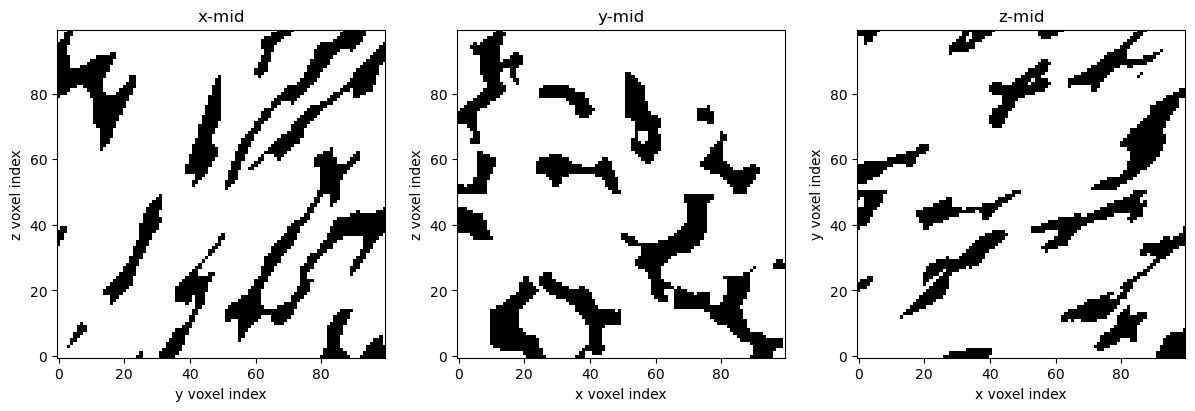

In [4]:
central_indices = tuple(v // 2 for v in marrow_roi.shape)
slice_specs = [
    ("x-mid", np.take(marrow_roi, central_indices[0], axis=0), "y", "z"),
    ("y-mid", np.take(marrow_roi, central_indices[1], axis=1), "x", "z"),
    ("z-mid", np.take(marrow_roi, central_indices[2], axis=2), "x", "y"),
]

fig, axes = plt.subplots(1, 3, figsize=(12, 4), constrained_layout=True)
for ax, (title, image, xlabel, ylabel) in zip(axes, slice_specs, strict=True):
    ax.imshow(image.T, cmap="gray", origin="lower", vmin=0, vmax=1)
    ax.set_title(title)
    ax.set_xlabel(f"{xlabel} voxel index")
    ax.set_ylabel(f"{ylabel} voxel index")

mask_fig_path = output_dir / "trabecular_bone_roi_binary_midplanes.png"
if save_outputs:
    fig.savefig(mask_fig_path, dpi=180)

mask_fig_path

## Extract 3-D pore networks and solve directional flow

Each backend receives the same binary marrow/pore ROI. For each requested
axis, the network is pruned to the axis-spanning subnetwork before solving
single-phase flow with the same fluid, pressure drop, and conductance settings.

In [5]:
def _diameter_array(container: dict[str, np.ndarray]) -> np.ndarray:
    """Return a best-available diameter array for pore or throat containers."""

    if "diameter_inscribed" in container:
        return np.asarray(container["diameter_inscribed"], dtype=float)
    if "equivalent_diameter" in container:
        return np.asarray(container["equivalent_diameter"], dtype=float)
    if "diameter_equivalent" in container:
        return np.asarray(container["diameter_equivalent"], dtype=float)
    if "radius_inscribed" in container:
        return 2.0 * np.asarray(container["radius_inscribed"], dtype=float)
    if "area" in container:
        return 2.0 * np.sqrt(np.asarray(container["area"], dtype=float) / np.pi)
    return np.asarray([], dtype=float)


def _length_array(container: dict[str, np.ndarray]) -> np.ndarray:
    """Return a best-available throat length array."""

    for key in ("length", "total_length", "direct_length"):
        if key in container:
            return np.asarray(container[key], dtype=float)
    return np.asarray([], dtype=float)


def _finite_stats(
    values: np.ndarray,
    *,
    prefix: str,
    scale: float = 1.0,
) -> dict[str, float | int]:
    """Compute compact finite-value statistics."""

    arr = np.asarray(values, dtype=float) * float(scale)
    finite = arr[np.isfinite(arr)]
    if finite.size == 0:
        return {
            f"{prefix}_count": 0,
            f"{prefix}_min": np.nan,
            f"{prefix}_p25": np.nan,
            f"{prefix}_median": np.nan,
            f"{prefix}_mean": np.nan,
            f"{prefix}_p75": np.nan,
            f"{prefix}_max": np.nan,
        }
    return {
        f"{prefix}_count": int(finite.size),
        f"{prefix}_min": float(np.min(finite)),
        f"{prefix}_p25": float(np.percentile(finite, 25.0)),
        f"{prefix}_median": float(np.median(finite)),
        f"{prefix}_mean": float(np.mean(finite)),
        f"{prefix}_p75": float(np.percentile(finite, 75.0)),
        f"{prefix}_max": float(np.max(finite)),
    }


def _network_stats_row(
    *,
    backend: str,
    backend_label: str,
    axis: str,
    extraction: Any,
    result: Any,
    extraction_seconds: float,
    solve_seconds: float,
) -> dict[str, object]:
    """Build a one-row network and transport summary."""

    net = extraction.net
    metrics = connectivity_metrics(net)
    degree = coordination_numbers(net)
    row: dict[str, object] = {
        "backend": backend,
        "backend_label": backend_label,
        "axis": axis,
        "n_pores_full": int(extraction.net_full.Np),
        "n_throats_full": int(extraction.net_full.Nt),
        "n_pores": int(net.Np),
        "n_throats": int(net.Nt),
        "image_porosity": float(marrow_roi.mean()),
        "network_absolute_porosity": float(absolute_porosity(net)),
        "network_effective_porosity": float(effective_porosity(net, axis=axis)),
        "n_components": int(metrics.n_components),
        "giant_component_fraction": float(metrics.giant_component_fraction),
        "isolated_pore_fraction": float(metrics.isolated_pore_fraction),
        "dead_end_fraction": float(metrics.dead_end_fraction),
        "mean_coordination": float(np.mean(degree) if degree.size else np.nan),
        "median_coordination": float(np.median(degree) if degree.size else np.nan),
        "k_m2": float(result.permeability[axis]),
        "k_mD": float(result.permeability[axis] / M2_PER_MD),
        "total_flow_rate": float(result.total_flow_rate),
        "mass_balance_error": float(result.mass_balance_error),
        "residual_norm": float(result.residual_norm),
        "extraction_seconds": float(extraction_seconds),
        "solve_seconds": float(solve_seconds),
    }
    row.update(
        _finite_stats(_diameter_array(net.pore), prefix="pore_diameter_um", scale=1.0e6)
    )
    row.update(
        _finite_stats(
            _diameter_array(net.throat), prefix="throat_diameter_um", scale=1.0e6
        )
    )
    row.update(
        _finite_stats(_length_array(net.throat), prefix="throat_length_um", scale=1.0e6)
    )
    return row


extractions: dict[tuple[str, str], Any] = {}
solutions: dict[tuple[str, str], Any] = {}
network_rows: list[dict[str, object]] = []
status_rows: list[dict[str, object]] = []
coordination_rows: list[dict[str, object]] = []

for backend_spec in backend_specs:
    backend = str(backend_spec["backend"])
    backend_label = str(backend_spec["label"])
    extraction_kwargs = dict(backend_spec["extraction_kwargs"])
    geometry_repairs = backend_spec["geometry_repairs"]

    for axis in flow_axes:
        if axis not in axis_index_by_label:
            status_rows.append(
                {
                    "backend": backend,
                    "backend_label": backend_label,
                    "axis": axis,
                    "status": "skipped",
                    "message": f"axis {axis!r} is not compatible with this ROI",
                }
            )
            continue
        if not image_spans[axis]:
            status_rows.append(
                {
                    "backend": backend,
                    "backend_label": backend_label,
                    "axis": axis,
                    "status": "skipped",
                    "message": f"marrow/pore phase does not span {axis}",
                }
            )
            continue

        try:
            start = time.perf_counter()
            extraction = extract_spanning_pore_network(
                marrow_roi.astype(np.int8),
                voxel_size=voxel_size_m,
                backend=backend,
                flow_axis=axis,
                length_unit="m",
                pressure_unit="Pa",
                extraction_kwargs=extraction_kwargs,
                provenance_notes={
                    "case": "trabecular_bone_3d_roi",
                    "raw_filename": raw_filename,
                    "raw_shape": raw_shape,
                    "raw_order": raw_order,
                    "phase_convention": "0=marrow_or_pore, 1=bone",
                    "roi_start": resolved_roi_start,
                    "roi_shape": roi_shape,
                    "scientific_scope": "3d_roi_pnm_reduction",
                },
                strict=True,
                geometry_repairs=geometry_repairs,
                repair_seed=0,
            )
            extraction_seconds = time.perf_counter() - start

            start = time.perf_counter()
            result = solve(
                extraction.net,
                fluid=fluid,
                bc=PressureBC(
                    inlet_label=f"inlet_{axis}min",
                    outlet_label=f"outlet_{axis}max",
                    pin=pressure_pin_pa,
                    pout=pressure_pout_pa,
                ),
                axis=axis,
                options=singlephase_options,
            )
            solve_seconds = time.perf_counter() - start

        except Exception as exc:
            status_rows.append(
                {
                    "backend": backend,
                    "backend_label": backend_label,
                    "axis": axis,
                    "status": "failed",
                    "message": f"{type(exc).__name__}: {exc}",
                }
            )
            continue

        key = (backend, axis)
        extractions[key] = extraction
        solutions[key] = result
        status_rows.append(
            {
                "backend": backend,
                "backend_label": backend_label,
                "axis": axis,
                "status": "ok",
                "message": "",
            }
        )
        network_rows.append(
            _network_stats_row(
                backend=backend,
                backend_label=backend_label,
                axis=axis,
                extraction=extraction,
                result=result,
                extraction_seconds=extraction_seconds,
                solve_seconds=solve_seconds,
            )
        )

        degree = coordination_numbers(extraction.net)
        degree_values, degree_counts = np.unique(degree, return_counts=True)
        for degree_value, degree_count in zip(
            degree_values, degree_counts, strict=True
        ):
            coordination_rows.append(
                {
                    "backend": backend,
                    "backend_label": backend_label,
                    "axis": axis,
                    "coordination": int(degree_value),
                    "pore_count": int(degree_count),
                    "pore_fraction": float(
                        degree_count / degree.size if degree.size else np.nan
                    ),
                }
            )

status_df = pd.DataFrame(status_rows)
network_stats_df = pd.DataFrame(network_rows)
coordination_histogram_df = pd.DataFrame(coordination_rows)

if network_stats_df.empty:
    raise RuntimeError("No backend/axis combination produced a solved pore network.")

display(status_df)

,backend,backend_label,axis,status,message
0,native_maximal_ball,Native maximal-ball,x,ok,
1,native_maximal_ball,Native maximal-ball,y,ok,
2,native_maximal_ball,Native maximal-ball,z,ok,
3,prego,PREGO,x,ok,
4,prego,PREGO,y,ok,
5,prego,PREGO,z,ok,
6,porespy,PoreSpy snow2,x,ok,
7,porespy,PoreSpy snow2,y,ok,
8,porespy,PoreSpy snow2,z,ok,


## Permeability estimates

The table reports Darcy-law permeability from the solved networks. These are
3-D ROI-scale PNM estimates and should be compared against direct-image or
micro-continuum solves using the same ROI and boundary-condition convention.

In [6]:
kabs_columns = [
    "backend_label",
    "axis",
    "k_m2",
    "k_mD",
    "n_pores",
    "n_throats",
    "network_absolute_porosity",
    "network_effective_porosity",
    "mass_balance_error",
    "extraction_seconds",
    "solve_seconds",
]
kabs_directional_df = network_stats_df[kabs_columns].sort_values(
    ["backend_label", "axis"]
)
display(kabs_directional_df)

kabs_summary_df = (
    network_stats_df.groupby(["backend", "backend_label"], sort=False)
    .agg(
        axis_count=("axis", "count"),
        k_mean_m2=("k_m2", "mean"),
        k_mean_mD=("k_mD", "mean"),
        k_rms_m2=(
            "k_m2",
            lambda s: float(np.sqrt(np.mean(np.square(s.to_numpy(dtype=float))))),
        ),
        k_rms_mD=(
            "k_mD",
            lambda s: float(np.sqrt(np.mean(np.square(s.to_numpy(dtype=float))))),
        ),
        n_pores_mean=("n_pores", "mean"),
        n_throats_mean=("n_throats", "mean"),
        mean_coordination=("mean_coordination", "mean"),
    )
    .reset_index()
)
display(kabs_summary_df)

,backend_label,axis,k_m2,k_mD,n_pores,n_throats,network_absolute_porosity,network_effective_porosity,mass_balance_error,extraction_seconds,solve_seconds
0,Native maximal-ball,x,1.073039e-10,108725.700330,80,236,0.804207,0.804207,2.356382e-27,1.811987,0.003712
1,Native maximal-ball,y,6.713505e-11,68024.590721,80,236,0.804207,0.804207,8.187941e-27,1.725648,0.001892
2,Native maximal-ball,z,7.964382e-11,80699.096270,80,236,0.804207,0.804207,1.815171e-27,1.791592,0.002289
3,PREGO,x,1.215529e-11,12316.350444,187,711,0.804081,0.804081,7.575300e-27,1.338752,0.003211
4,PREGO,y,8.341725e-12,8452.252484,187,711,0.804081,0.804081,7.745383e-27,1.219536,0.002255
5,PREGO,z,9.231694e-12,9354.013693,187,711,0.804081,0.804081,5.003566e-27,1.249536,0.002472
6,PoreSpy snow2,x,2.040424e-11,20674.596358,391,788,0.901599,0.901599,1.127460e-26,2.659857,0.007401
7,PoreSpy snow2,y,8.625967e-12,8740.260840,391,788,0.901599,0.901599,1.491959e-26,1.404033,0.004857
8,PoreSpy snow2,z,1.260888e-11,12775.943333,391,788,0.901599,0.901599,7.806277e-27,1.395867,0.006237


,backend,backend_label,axis_count,k_mean_m2,k_mean_mD,k_rms_m2,k_rms_mD,n_pores_mean,n_throats_mean,mean_coordination
0,native_maximal_ball,Native maximal-ball,3,8.469427e-11,85816.462440,8.634116e-11,87485.173970,80.0,236.0,5.900000
1,prego,PREGO,3,9.909571e-12,10040.872207,1.004257e-11,10175.634828,187.0,711.0,7.604278
2,porespy,PoreSpy snow2,3,1.387969e-11,14063.600177,1.471648e-11,14911.470106,391.0,788.0,4.030691


## Network statistics

In [7]:
stats_columns = [
    "backend_label",
    "axis",
    "n_pores_full",
    "n_throats_full",
    "n_pores",
    "n_throats",
    "image_porosity",
    "network_absolute_porosity",
    "network_effective_porosity",
    "n_components",
    "giant_component_fraction",
    "isolated_pore_fraction",
    "dead_end_fraction",
    "mean_coordination",
    "median_coordination",
    "pore_diameter_um_median",
    "throat_diameter_um_median",
    "throat_length_um_median",
]
display(network_stats_df[stats_columns].sort_values(["backend_label", "axis"]))

coordination_pivot = coordination_histogram_df.pivot_table(
    index=["backend_label", "axis"],
    columns="coordination",
    values="pore_count",
    fill_value=0,
    aggfunc="sum",
)
display(coordination_pivot)

,backend_label,axis,n_pores_full,n_throats_full,n_pores,n_throats,image_porosity,network_absolute_porosity,network_effective_porosity,n_components,giant_component_fraction,isolated_pore_fraction,dead_end_fraction,mean_coordination,median_coordination,pore_diameter_um_median,throat_diameter_um_median,throat_length_um_median
0,Native maximal-ball,x,81,236,80,236,0.805479,0.804207,0.804207,1,1.0,0.0,0.087500,5.900000,5.0,29.132721,14.319896,76.175028
1,Native maximal-ball,y,81,236,80,236,0.805479,0.804207,0.804207,1,1.0,0.0,0.087500,5.900000,5.0,29.132721,14.319896,76.175028
2,Native maximal-ball,z,81,236,80,236,0.805479,0.804207,0.804207,1,1.0,0.0,0.087500,5.900000,5.0,29.132721,14.319896,76.175028
3,PREGO,x,190,712,187,711,0.805479,0.804081,0.804081,1,1.0,0.0,0.021390,7.604278,7.0,21.273109,20.438543,53.168056
4,PREGO,y,190,712,187,711,0.805479,0.804081,0.804081,1,1.0,0.0,0.021390,7.604278,7.0,21.273109,20.438543,53.168056
5,PREGO,z,190,712,187,711,0.805479,0.804081,0.804081,1,1.0,0.0,0.021390,7.604278,7.0,21.273109,20.438543,53.168056
6,PoreSpy snow2,x,405,797,391,788,0.805479,0.901599,0.901599,1,1.0,0.0,0.511509,4.030691,1.0,8.344000,20.860000,44.693969
7,PoreSpy snow2,y,405,797,391,788,0.805479,0.901599,0.901599,1,1.0,0.0,0.511509,4.030691,1.0,8.344000,20.860000,44.693969
8,PoreSpy snow2,z,405,797,391,788,0.805479,0.901599,0.901599,1,1.0,0.0,0.511509,4.030691,1.0,8.344000,20.860000,44.693969


coordination               1   2   3   4   5   6   7   8   9   10  ...  15  \
backend_label       axis                                           ...       
Native maximal-ball x       7   7  12  11   7   8   7   4   5   4  ...   0   
                    y       7   7  12  11   7   8   7   4   5   4  ...   0   
                    z       7   7  12  11   7   8   7   4   5   4  ...   0   
PREGO               x       4   7  15  18  23  19  18  19   7  18  ...   6   
                    y       4   7  15  18  23  19  18  19   7  18  ...   6   
                    z       4   7  15  18  23  19  18  19   7  18  ...   6   
PoreSpy snow2       x     200   6  18  25  27  26  22  15  13  10  ...   2   
                    y     200   6  18  25  27  26  22  15  13  10  ...   2   
                    z     200   6  18  25  27  26  22  15  13  10  ...   2   

coordination              16  17  18  19  20  21  23  24  26  
backend_label       axis                                      
Native maximal-ball x      0   0   0   1   0   1   1   0   0  
                    y      0   0   0   1   0   1   1   0   0  
                    z      0   0   0   1   0   1   1   0   0  
PREGO               x      1   2   1   1   2   0   1   0   0  
                    y      1   2   1   1   2   0   1   0   0  
                    z      1   2   1   1   2   0   1   0   0  
PoreSpy snow2       x      0   3   0   1   1   0   1   1   1  
                    y      0   3   0   1   1   0   1   1   1  
                    z      0   3   0   1   1   0   1   1   1  

[9 rows x 24 columns]

## Diagnostic plots for one extracted network

Plotted backend: native_maximal_ball, axis: x
Kx: 1.073039e-10 m^2
Kx: 108725.700330 mD


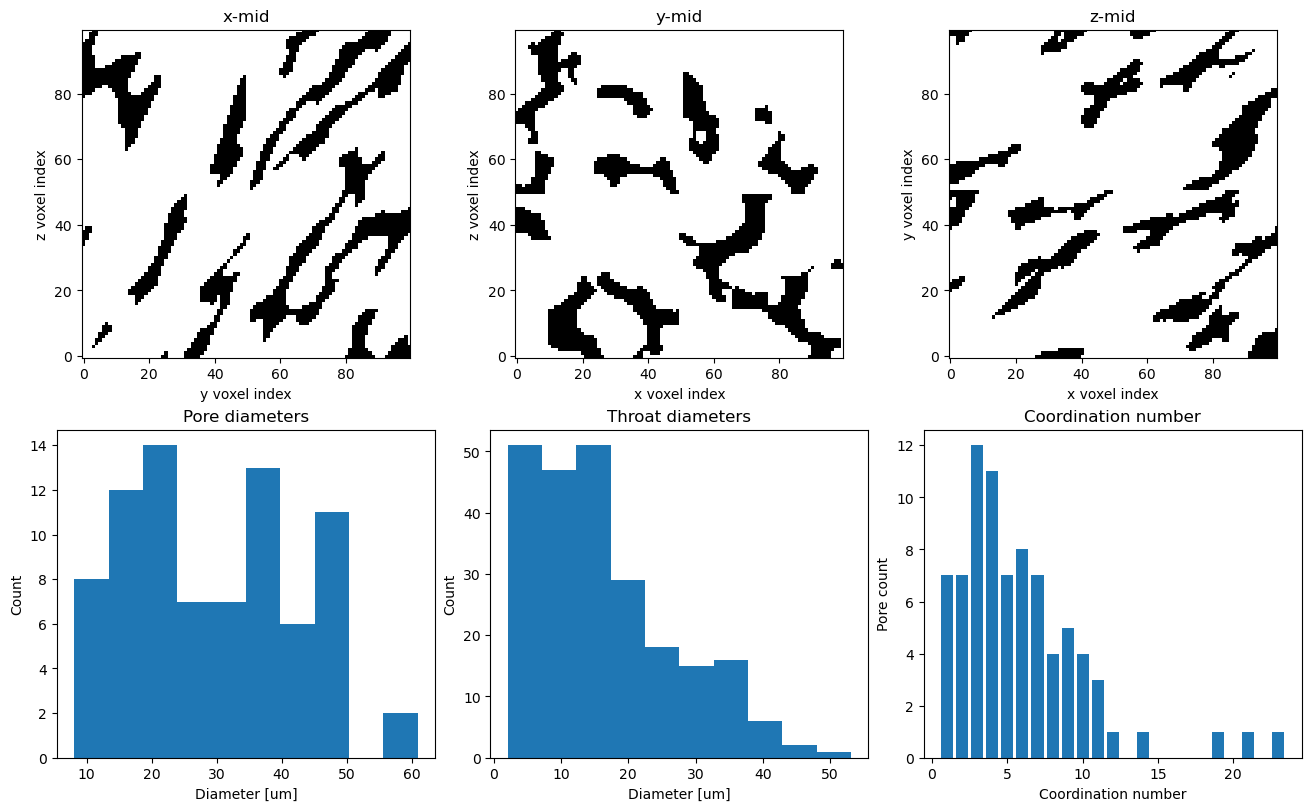

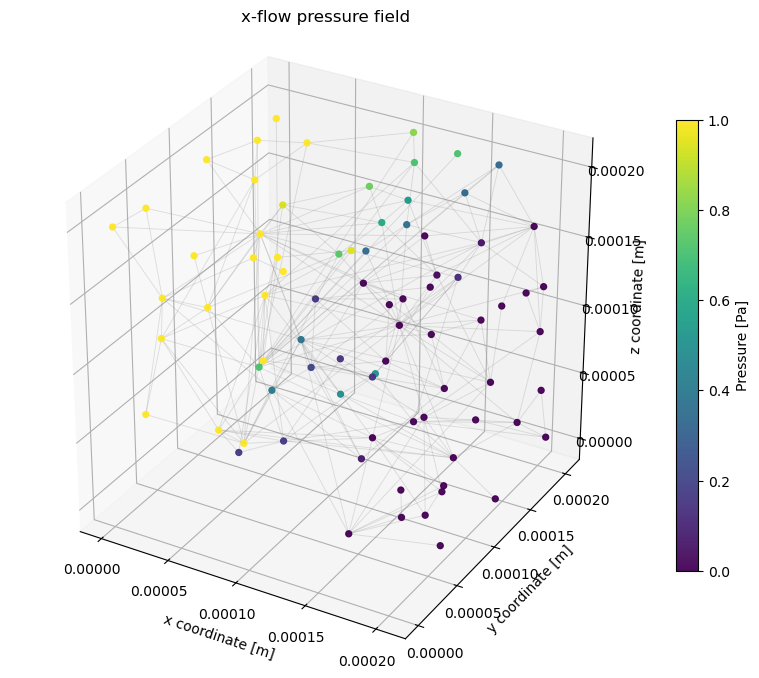

In [8]:
def _select_primary_key() -> tuple[str, str]:
    requested = (primary_backend, primary_axis)
    if requested in extractions:
        return requested
    for backend_spec in backend_specs:
        for axis in flow_axes:
            candidate = (str(backend_spec["backend"]), axis)
            if candidate in extractions:
                return candidate
    raise RuntimeError("No solved network is available for plotting.")


def _plot_network_3d(
    *,
    net: Any,
    pore_pressure: np.ndarray,
    axis: str,
    ax: Any,
    max_throats: int | None = 2_000,
) -> None:
    """Plot a 3-D pore network with pressure-colored pores."""

    coords = np.asarray(net.pore_coords, dtype=float)
    conns = np.asarray(net.throat_conns, dtype=int)
    if max_throats is not None and conns.shape[0] > max_throats:
        idx = np.linspace(0, conns.shape[0] - 1, max_throats, dtype=int)
        conns = conns[idx]

    for i, j in conns:
        ax.plot(
            [coords[i, 0], coords[j, 0]],
            [coords[i, 1], coords[j, 1]],
            [coords[i, 2], coords[j, 2]],
            color="0.55",
            alpha=0.25,
            linewidth=0.65,
            zorder=1,
        )

    scatter = ax.scatter(
        coords[:, 0],
        coords[:, 1],
        coords[:, 2],
        c=np.asarray(pore_pressure, dtype=float),
        s=18,
        cmap="viridis",
        alpha=0.95,
        zorder=2,
    )
    ax.set_title(f"{axis}-flow pressure field")
    ax.set_xlabel("x coordinate [m]")
    ax.set_ylabel("y coordinate [m]")
    ax.set_zlabel("z coordinate [m]")
    spans = np.maximum(np.ptp(coords, axis=0), np.finfo(float).eps)
    ax.set_box_aspect(spans)
    plt.colorbar(scatter, ax=ax, label="Pressure [Pa]", shrink=0.7)


plot_backend, plot_axis = _select_primary_key()
plot_extraction = extractions[(plot_backend, plot_axis)]
plot_solution = solutions[(plot_backend, plot_axis)]
plot_net = plot_extraction.net

pore_diameter_um = _diameter_array(plot_net.pore) * 1.0e6
throat_diameter_um = _diameter_array(plot_net.throat) * 1.0e6
coordination = coordination_numbers(plot_net)

fig, axes = plt.subplots(2, 3, figsize=(13, 8), constrained_layout=True)
for ax, (title, image, xlabel, ylabel) in zip(axes[0], slice_specs, strict=True):
    ax.imshow(image.T, cmap="gray", origin="lower", vmin=0, vmax=1)
    ax.set_title(title)
    ax.set_xlabel(f"{xlabel} voxel index")
    ax.set_ylabel(f"{ylabel} voxel index")

axes[1, 0].hist(pore_diameter_um[np.isfinite(pore_diameter_um)])
axes[1, 0].set_title("Pore diameters")
axes[1, 0].set_xlabel("Diameter [um]")
axes[1, 0].set_ylabel("Count")

axes[1, 1].hist(throat_diameter_um[np.isfinite(throat_diameter_um)])
axes[1, 1].set_title("Throat diameters")
axes[1, 1].set_xlabel("Diameter [um]")
axes[1, 1].set_ylabel("Count")

coord_values, coord_counts = np.unique(coordination, return_counts=True)
axes[1, 2].bar(coord_values, coord_counts, width=0.8)
axes[1, 2].set_title("Coordination number")
axes[1, 2].set_xlabel("Coordination number")
axes[1, 2].set_ylabel("Pore count")

distribution_fig_path = output_dir / (
    f"trabecular_bone_roi_{plot_backend}_{plot_axis}_network_distributions.png"
)
if save_outputs:
    fig.savefig(distribution_fig_path, dpi=180)

fig = plt.figure(figsize=(7.5, 6.8), constrained_layout=True)
ax = fig.add_subplot(111, projection="3d")
_plot_network_3d(
    net=plot_net,
    pore_pressure=plot_solution.pore_pressure,
    axis=plot_axis,
    ax=ax,
)
network_fig_path = output_dir / (
    f"trabecular_bone_roi_{plot_backend}_{plot_axis}_network_pressure.png"
)
if save_outputs:
    fig.savefig(network_fig_path, dpi=220)

print(f"Plotted backend: {plot_backend}, axis: {plot_axis}")
print(f"K{plot_axis}: {plot_solution.permeability[plot_axis]:.6e} m^2")
print(f"K{plot_axis}: {plot_solution.permeability[plot_axis] / M2_PER_MD:.6f} mD")

## Save network and summary artifacts

In [9]:
saved_paths: list[Path] = []

if save_outputs:
    roi_mask_path = output_dir / "trabecular_bone_roi_marrow_mask.npy"
    np.save(roi_mask_path, marrow_roi.astype(np.uint8))
    saved_paths.append(roi_mask_path)

    image_summary_path = output_dir / "trabecular_bone_roi_image_summary.csv"
    phase_summary_path = output_dir / "trabecular_bone_roi_phase_summary.csv"
    kabs_directional_path = output_dir / "trabecular_bone_roi_kabs_directional.csv"
    kabs_summary_path = output_dir / "trabecular_bone_roi_kabs_summary_by_backend.csv"
    network_stats_path = output_dir / "trabecular_bone_roi_network_stats.csv"
    coordination_histogram_path = (
        output_dir / "trabecular_bone_roi_coordination_histogram.csv"
    )

    image_summary.to_csv(image_summary_path, index=False)
    phase_summary.to_csv(phase_summary_path, index=False)
    kabs_directional_df.to_csv(kabs_directional_path, index=False)
    kabs_summary_df.to_csv(kabs_summary_path, index=False)
    network_stats_df.to_csv(network_stats_path, index=False)
    coordination_histogram_df.to_csv(coordination_histogram_path, index=False)

    saved_paths.extend(
        [
            image_summary_path,
            phase_summary_path,
            kabs_directional_path,
            kabs_summary_path,
            network_stats_path,
            coordination_histogram_path,
            mask_fig_path,
            distribution_fig_path,
            network_fig_path,
        ]
    )

    for (backend, axis), extraction in extractions.items():
        net_path = output_dir / (
            f"trabecular_bone_roi_{backend}_{axis}spanning_network_voids.h5"
        )
        save_hdf5(extraction.net, net_path)
        saved_paths.append(net_path)

pd.DataFrame({"saved_path": [str(path) for path in saved_paths]})

,saved_path
0,/Users/dtvolpatto/Work/voids/notebooks/outputs...
1,/Users/dtvolpatto/Work/voids/notebooks/outputs...
2,/Users/dtvolpatto/Work/voids/notebooks/outputs...
3,/Users/dtvolpatto/Work/voids/notebooks/outputs...
4,/Users/dtvolpatto/Work/voids/notebooks/outputs...
5,/Users/dtvolpatto/Work/voids/notebooks/outputs...
6,/Users/dtvolpatto/Work/voids/notebooks/outputs...
7,/Users/dtvolpatto/Work/voids/notebooks/outputs...
8,/Users/dtvolpatto/Work/voids/notebooks/outputs...
9,/Users/dtvolpatto/Work/voids/notebooks/outputs...


## Interpretation notes

- The ROI has high marrow/pore fraction and spans all three axes, so the PNM
  solves are mathematically well posed for this image subset.
- Backend-to-backend spread is a real modeling signal here. Different
  extraction backends place pore bodies and throats differently, so the
  reported permeability is not backend-invariant.
- This is a pore-network reduction of the segmented void space. It should be
  compared separately from coefficient-field Darcy or micro-continuum FEM
  solves, which use porosity and permeability maps rather than explicit
  extracted throat geometry.